In [24]:
import uproot, pandas as pd, numpy as np
from pathlib import Path

# config
BASE_DIR = Path(".")
TREE_NAME = "AnalysisMiniTree"
RUN = 2
PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# columns to exclude from features (weights, IDs, truth info, preselection constants)
BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti", "dsid", "eventnumber"]
BLOCK_EXACT = {"n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
               "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans", "pair_isOStaus", "tau2_baseline_RNNTight", "pair_isOSleptau", "l1_dOsig"}
BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}

def is_feature(branch):
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s in lb for s in BLOCK_SUBSTR)

WEIGHT_PARTS = ["weight", "weights"]  # w_phys = product of these

files = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

# use only branches present in every file
common = None
for fname, _ in files.values():
    keys = set(uproot.open({str(BASE_DIR / fname): TREE_NAME}).keys())
    common = keys if common is None else common & keys
features = sorted(b for b in common if is_feature(b))

print(f"{len(features)} candidate features common to all {len(files)} files\n")

88 candidate features common to all 10 files



In [26]:
# extraction loop
dfs = []
for proc, (fname, label) in files.items():
    tree = uproot.open({str(BASE_DIR / fname): TREE_NAME})
    df = tree.arrays(features + WEIGHT_PARTS, cut=PRESELECTION, library="pd")

    df["w_phys"] = df["weight"] * df["weights"]  # physical event weight
    df["label"] = label
    df["process"] = proc
    df["run"] = RUN
    dfs.append(df)
    print(f"{proc:12s}: {len(df):>8d} events after preselection")

data = pd.concat(dfs, ignore_index=True)

signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection


In [27]:
# drop fully empty branches (all-NaN across every event)
empty_cols = [f for f in features if data[f].isna().all()]
features = [f for f in features if f not in empty_cols]
data = data.drop(columns=empty_cols)

print(f"Dropped {len(empty_cols)} fully empty branches: {sorted(empty_cols)}")
print(f"{len(features)} features remaining")

Dropped 8 fully empty branches: ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1']
80 features remaining


In [28]:
# post-concatenate cleaning
# 1) drop constant features
nun = data[features].nunique()
const = nun[nun <= 1].index.tolist()
features = [f for f in features if f not in const]
data = data.drop(columns=const)
print(f"Dropped {len(const)} constant features: {sorted(const)}")

# 2) sentinel values (e.g. -999) -> NaN
for f in features:
    m = data[f] < -100
    if m.any():
        print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
        data[f] = data[f].mask(m)

print(f"\n{len(features)} final features")
print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | background = {(data.label==0).sum()}")
print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
data.head()

Dropped 11 constant features: ['n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode', 'tau2_passOR']

69 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | background = 11467.29


,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_eta,tau2_nprong,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,486197.28125,437935.43750,350626.937500,42837.089844,91098.921875,44471.410156,77389.632812,91956.718750,12270.166016,2.849011,...,0.794897,1,-3.045134,22102.740234,0.00125,-0.028450,-0.000036,1,signal_ggF,2
1,233307.37500,192779.18750,92852.828125,31019.406250,71547.601562,68906.953125,35689.703125,32890.671875,20957.582031,2.693458,...,2.437175,1,1.528327,30261.955078,0.00125,0.054811,0.000069,1,signal_ggF,2
2,399998.12500,345424.46875,107697.429688,164906.187500,219479.843750,72820.843750,127177.953125,97451.046875,33988.949219,0.399682,...,0.301610,1,0.593764,33664.312500,0.00125,0.029853,0.000037,1,signal_ggF,2
3,344867.65625,249412.12500,165593.328125,21953.849609,117409.382812,61864.949219,36656.707031,111334.617188,18972.347656,2.708711,...,1.256151,1,0.694036,21605.847656,0.00125,0.030944,0.000039,1,signal_ggF,2
4,326392.68750,270753.15625,128916.000000,71331.773438,126971.281250,70505.390625,129401.234375,129401.234375,55308.082031,2.955379,...,-0.066556,1,-1.724129,31729.716797,0.00125,0.032416,0.000041,1,signal_ggF,2


In [29]:
print(data.shape)

(690684, 75)


## XGBOOST

In [30]:
from sklearn.model_selection import train_test_split

# 80/20 train-validation split, stratified by label
train_df, val_df = train_test_split(
    data, test_size=0.20, random_state=42, stratify=data["label"]
)

X_train, y_train, w_train = train_df[features], train_df["label"], train_df["w_phys"]
X_val, y_val, w_val = val_df[features], val_df["label"], val_df["w_phys"]

print(f"Train: {len(train_df)} events | signal = {(y_train==1).sum()} | background = {(y_train==0).sum()}")
print(f"Val:   {len(val_df)} events | signal = {(y_val==1).sum()} | background = {(y_val==0).sum()}")

Train: 552547 events | signal = 70971 | background = 481576
Val:   138137 events | signal = 17743 | background = 120394


In [31]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# training weights: abs value (negatives corrupt gradients), rebalanced for class
# imbalance, normalized to mean 1
w_fit = np.abs(w_train.to_numpy())
sum_sig, sum_bkg = w_fit[y_train == 1].sum(), w_fit[y_train == 0].sum()
w_fit[y_train == 1] *= sum_bkg / sum_sig
w_fit *= len(w_fit) / w_fit.sum()

w_val_fit = np.abs(w_val.to_numpy())

print(f"signal weight scale factor: {sum_bkg/sum_sig:.1f}")

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)

model.fit(
    X_train, y_train,
    sample_weight=w_fit,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[w_val_fit],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")
auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1], sample_weight=np.abs(w_train))
auc_val   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1],   sample_weight=w_val_fit)
print(f"Weighted AUC: train = {auc_val:.4f} | validation = {auc_val:.4f}")

signal weight scale factor: 8844.6
[0]	validation_0-auc:0.90302
[50]	validation_0-auc:0.93498
[100]	validation_0-auc:0.93976
[150]	validation_0-auc:0.94303
[200]	validation_0-auc:0.94393
[250]	validation_0-auc:0.94456
[300]	validation_0-auc:0.94501

Best iteration: 270
Weighted AUC: train = 0.9452 | validation = 0.9452


Top 25 features by total gain:
                total_gain  gain_frac  weight
HT_tau       744700.000000   0.320331   384.0
tau1_pt      288986.687500   0.124307   296.0
dR_t1t2      136275.875000   0.058619   565.0
met_sumet     78092.937500   0.033591   375.0
m_t1t2        77656.804688   0.033404   609.0
SumPt_t1t2    73056.742188   0.031425   451.0
dR_l1j1       66131.562500   0.028446   361.0
HT            61858.261719   0.026608   269.0
tau2_pt       53406.566406   0.022973   394.0
m_l1j         47875.742188   0.020594   317.0
met_met       36867.597656   0.015859   400.0
m_ttl         28669.996094   0.012332   303.0
m_l1j1        27167.273438   0.011686   315.0
dR_t1t2_l1    26491.445312   0.011395   350.0
m_l1t1        24700.037109   0.010625   324.0
HT_lepMET     22468.886719   0.009665   327.0
m_l1t         22135.771484   0.009522   307.0
tau1_eta      21897.662109   0.009419   367.0
dR_l1t        21007.333984   0.009036   330.0
j1_pt         19785.779297   0.008511   305.0
dR_

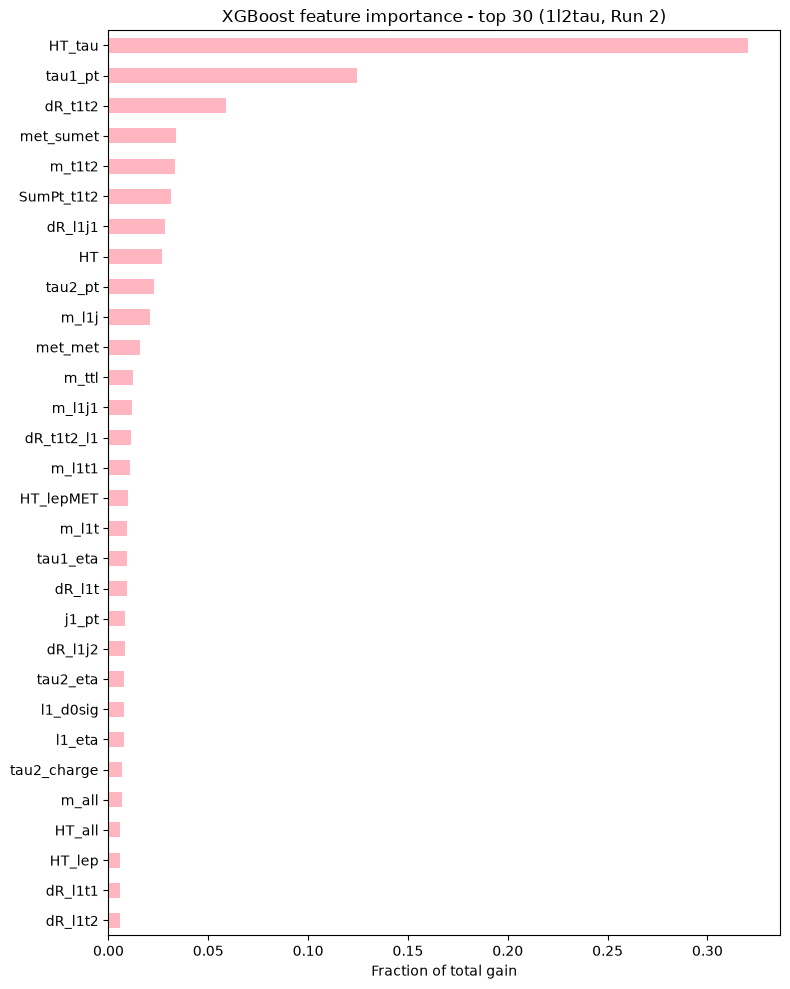

In [32]:
import matplotlib.pyplot as plt

# feature importance, ranked by total gain
booster = model.get_booster()

imp = pd.DataFrame({
    t: booster.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(features).fillna(0.0)

imp = imp.sort_values("total_gain", ascending=False)
imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()

print("Top 25 features by total gain:")
print(imp[["total_gain", "gain_frac", "weight"]].head(25).to_string())
print(f"\nFeatures never used in a split: {(imp['total_gain'] == 0).sum()} / {len(features)}")

TOP_N = 30
fig, ax = plt.subplots(figsize=(8, 10))
imp["gain_frac"].head(TOP_N)[::-1].plot.barh(ax=ax, color="lightpink")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance - top {TOP_N} (1l2tau, Run 2)")
plt.tight_layout()
plt.show()

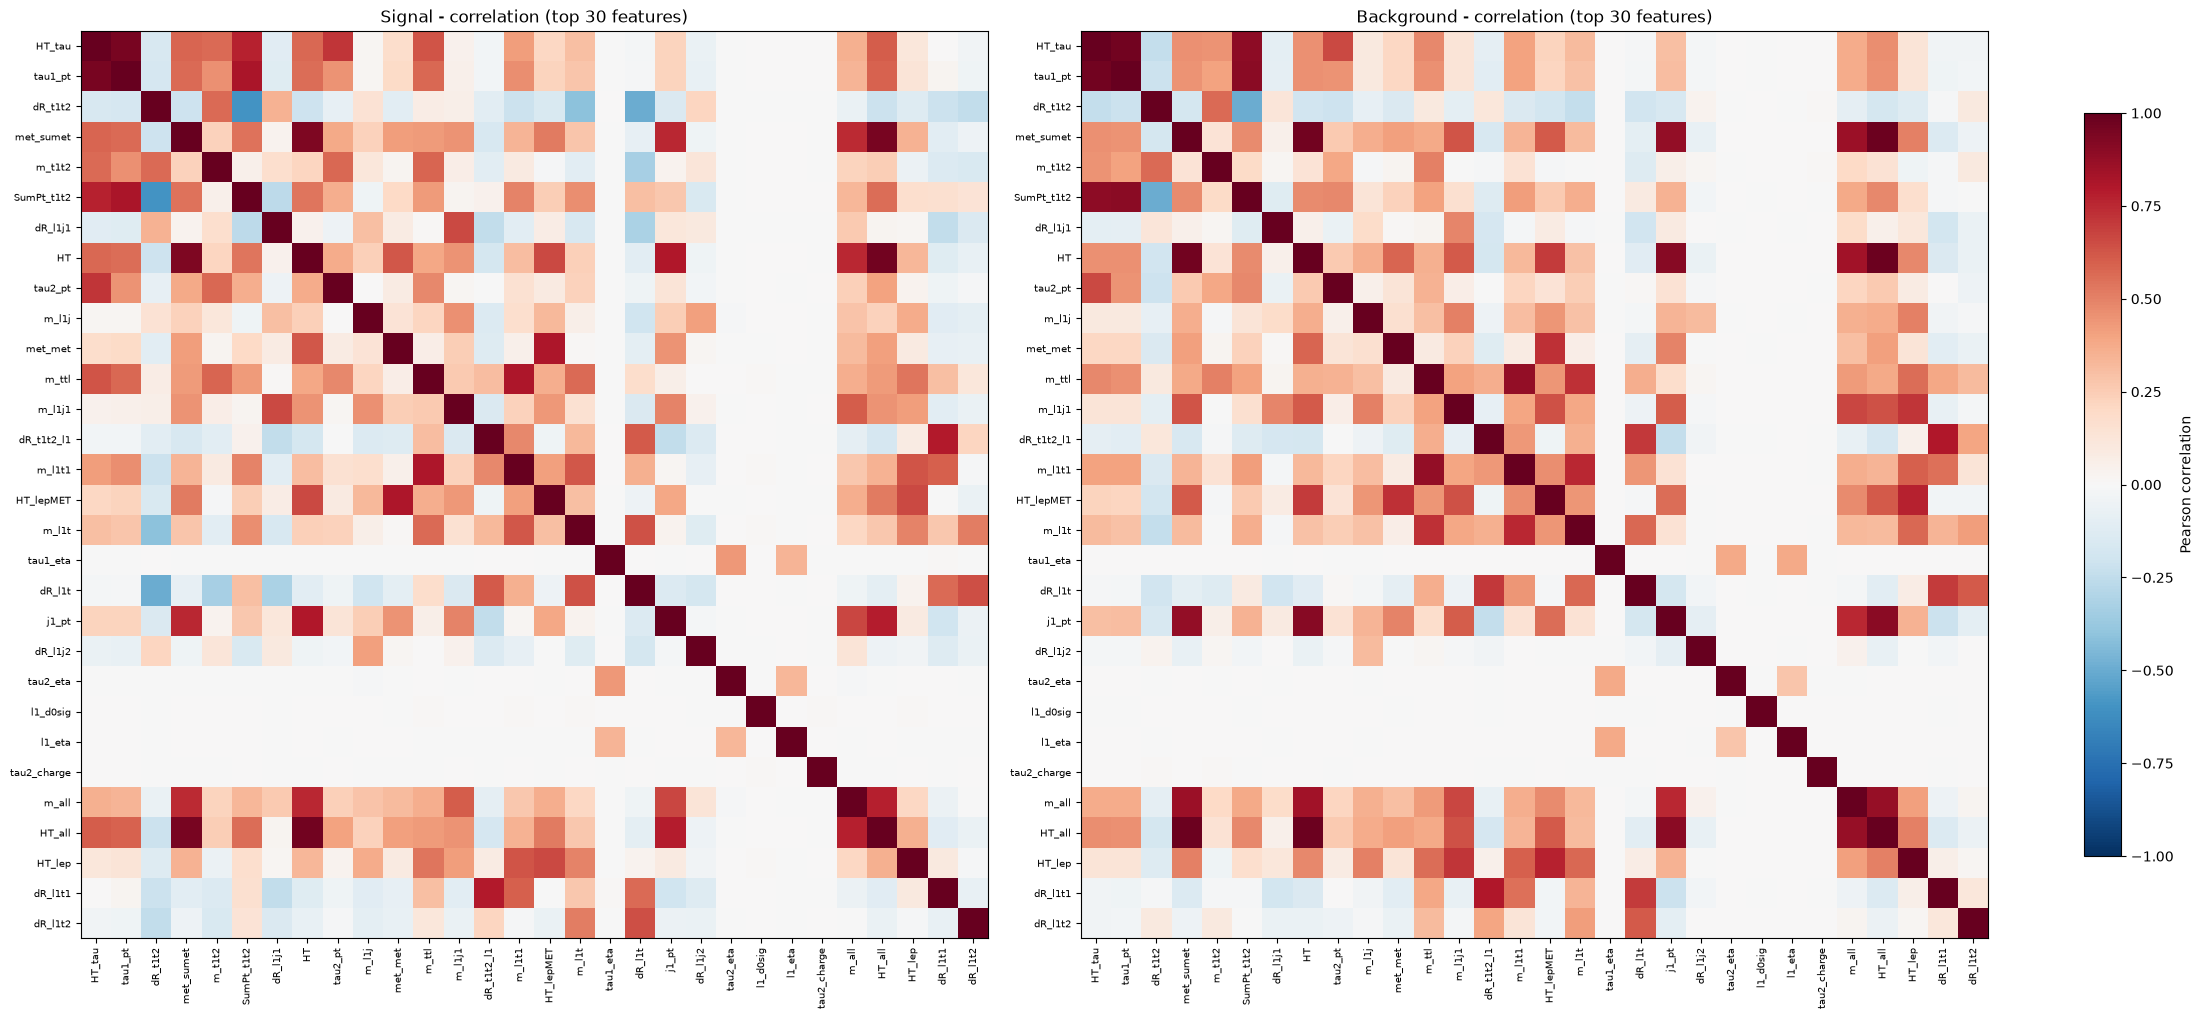

Pairs with |corr| > 0.9 (signal):
HT         HT_all     0.968501
met_sumet  HT_all     0.951155
HT_tau     tau1_pt    0.945766
met_sumet  HT         0.930010

Pairs with |corr| > 0.9 (background):
met_sumet  HT_all        0.983736
HT         HT_all        0.980366
HT_tau     tau1_pt       0.967306
met_sumet  HT            0.965350
HT         j1_pt         0.909921
tau1_pt    SumPt_t1t2    0.903307
j1_pt      HT_all        0.900532


In [34]:
# correlation of top features, signal vs background
top_feats = imp.index[:TOP_N].tolist()

corr_sig = data.loc[data.label == 1, top_feats].corr()
corr_bkg = data.loc[data.label == 0, top_feats].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
for ax, corr, title in [(axes[0], corr_sig, "Signal"), (axes[1], corr_bkg, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=90, fontsize=7)
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats, fontsize=7)
    ax.set_title(f"{title} - correlation (top {TOP_N} features)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")
plt.show()

# highly correlated pairs (candidates to prune)
def top_pairs(corr, thr=0.9):
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]

print("Pairs with |corr| > 0.9 (signal):")
print(top_pairs(corr_sig).to_string())
print("\nPairs with |corr| > 0.9 (background):")
print(top_pairs(corr_bkg).to_string())

## Optuna

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# tune on training partition only; X_val is untouched until after tuning
OPTUNA_FEATURES = top_feats.copy()
N_TRIALS = 15
N_FOLDS = 3

X_opt = X_train[OPTUNA_FEATURES].reset_index(drop=True)
y_opt = y_train.reset_index(drop=True).to_numpy()
w_opt = np.abs(w_train.reset_index(drop=True).to_numpy())


def make_fit_weights(labels, abs_weights):
    # balance signal/background, normalize mean weight to 1
    fit_weights = abs_weights.copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()
    return fit_weights


def objective(trial):
    params = {
        "n_estimators": 1200,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
        "tree_method": "hist",
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "n_jobs": -1,
        "random_state": 42,
    }

    fold_aucs = []
    best_iterations = []
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    for fold, (idx_train, idx_valid) in enumerate(cv.split(X_opt, y_opt)):
        fold_model = xgb.XGBClassifier(**params)
        fold_weights = make_fit_weights(y_opt[idx_train], w_opt[idx_train])

        fold_model.fit(
            X_opt.iloc[idx_train], y_opt[idx_train],
            sample_weight=fold_weights,
            eval_set=[(X_opt.iloc[idx_valid], y_opt[idx_valid])],
            sample_weight_eval_set=[w_opt[idx_valid]],
            verbose=False,
        )

        predictions = fold_model.predict_proba(X_opt.iloc[idx_valid])[:, 1]
        fold_auc = roc_auc_score(y_opt[idx_valid], predictions, sample_weight=w_opt[idx_valid])
        fold_aucs.append(fold_auc)
        best_iterations.append(fold_model.best_iteration + 1)

        trial.report(float(np.mean(fold_aucs)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("mean_best_iteration", int(round(np.mean(best_iterations))))
    trial.set_user_attr("fold_aucs", [float(value) for value in fold_aucs])
    return float(np.mean(fold_aucs))


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    study_name="xgb_1l2tau_run2_top15",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True, gc_after_trial=True)

print(f"\nCompleted trials: {len(study.trials)}")
print(f"Best mean CV AUC: {study.best_value:.5f}")
print(f"Mean best iteration: {study.best_trial.user_attrs['mean_best_iteration']}")
print("Fold AUCs:", study.best_trial.user_attrs["fold_aucs"])
print("Best parameters:")
for name, value in study.best_params.items():
    print(f"  {name}: {value}")

In [ ]:
# final model, using CV-selected tree count. No early stopping on X_val,
# so its AUC stays a clean holdout estimate.
best_n_estimators = study.best_trial.user_attrs["mean_best_iteration"]
best_params = {
    **study.best_params,
    "n_estimators": best_n_estimators,
    "tree_method": "hist",
    "eval_metric": "auc",
    "n_jobs": -1,
    "random_state": 42,
}

final_w_fit = make_fit_weights(y_train.to_numpy(), np.abs(w_train.to_numpy()))
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train[OPTUNA_FEATURES], y_train, sample_weight=final_w_fit, verbose=False)

pred_train = final_model.predict_proba(X_train[OPTUNA_FEATURES])[:, 1]
pred_holdout = final_model.predict_proba(X_val[OPTUNA_FEATURES])[:, 1]
w_holdout_abs = np.abs(w_val.to_numpy())

auc_train_opt = roc_auc_score(y_train, pred_train, sample_weight=final_w_fit)
auc_holdout_opt = roc_auc_score(y_val, pred_holdout, sample_weight=w_holdout_abs)
auc_holdout_unweighted = roc_auc_score(y_val, pred_holdout)

print(f"Features: {len(OPTUNA_FEATURES)}")
print(f"Trees: {best_n_estimators}")
print(f"Weighted AUC train:       {auc_train_opt:.5f}")
print(f"Weighted AUC Run-2 holdout: {auc_holdout_opt:.5f}")
print(f"Unweighted AUC holdout:   {auc_holdout_unweighted:.5f}")
print(f"Overtraining gap:         {auc_train_opt - auc_holdout_opt:.5f}")

In [ ]:
from sklearn.metrics import roc_curve

# optuna diagnostics + holdout ROC
trials = study.trials_dataframe()
complete = trials.loc[trials["state"] == "COMPLETE"].copy()
param_importance = optuna.importance.get_param_importances(study)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
axes[0].plot(complete["number"], complete["value"].cummax(), color="black", linewidth=2, label="best so far")
axes[0].set(xlabel="Trial", ylabel="Mean 3-fold AUC", title="Optuna history")
axes[0].legend()

names = list(param_importance)
values = [param_importance[name] for name in names]
axes[1].barh(names[::-1], values[::-1], color="steelblue")
axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

fpr, tpr, _ = roc_curve(y_val, pred_holdout, sample_weight=w_holdout_abs)
axes[2].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_holdout_opt:.4f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray")
axes[2].set(xlabel="False-positive rate", ylabel="True-positive rate",
            title="Run-2 holdout ROC", xlim=(0, 1), ylim=(0, 1))
axes[2].legend(loc="lower right")
plt.show()

print("Final Optuna features:")
print(OPTUNA_FEATURES)